# Minimal CEAP Attribution and Greedy Circuit Selection Example

This tutorial runs CEAP attribution on one SVA template, checks the resulting edge scores, and then uses greedy selection to evaluate circuits at several target edge counts.


In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from types import SimpleNamespace
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
from ceap.attribute import attribute
from ceap.graph import Graph
from pareto_dev_utils import (
    circuit_selection_data_collection_per_sample,
    evaluate_baseline_clean_corrupted,
    get_task_metrics,
    load_model,
    normalize_ig_style,
    prepare_dataloaders_for_different_templates,
)


### 1. Setup

In the cell below, `scoring_sample_number` is the total number of samples that we use for attribution. `max_n_data` is the total number of samples used. Samples that are not used for attribution may be used as "testing" samples to see how well the discovered circuits generalize.
You can also change the `model` to `csp_sweep1_4x_3.7Mnonzero_afrac1.000` and `task` to `else_elif` to try one of the sparse models offered by [Gao et al., 2025](https://arxiv.org/pdf/2511.13653).

In [ ]:
# Simulate argparse.Namespace with SimpleNamespace
args = SimpleNamespace(
    model='gpt2',
    task='sva',
    metric='prob_diff',
    div_for_scoring=False,
    ig_style='ceap',
    integrated_steps=200,
    scoring_sample_number=1000,
    evaluating_batch_size=256,
    max_n_data=1000, # In this example, we are not using testing dataset. Empirically, there is no difference between the unfaithfulness on the training data and on the testing data.
    seed=4,
)


n_edges_target_ls = [50, 500, 1000, 1500,]
normalize_ig_style(args) # to avoid configuration conflicts

print('IG style:', args.ig_style, '| integrated_steps:', args.integrated_steps)


### 2. Dataloading

In [34]:
print('Loading model and graph...')
model = load_model(args.model)
graph = Graph.from_model(model)


Loading model and graph...


/home/zwu/miniconda3/envs/ceap/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded pretrained model gpt2 into HookedTransformer


The next cell loads the data that will be used for attribution. `prepare_dataloaders_for_different_templates` loads a list of dataloaders. Each dataloader contains only samples generated by the same template. In this example, we use only one dataloader/template for demonstration.

In [35]:
train_dataloader_ls, _, template_label_ls = prepare_dataloaders_for_different_templates(
    task=args.task,
    model_name=args.model,
    max_n_data=args.max_n_data,
    scoring_sample_number=args.scoring_sample_number,
    evaluating_batch_size=args.evaluating_batch_size,
    seed=args.seed,
    return_df=False,
)

template_index, train_dataloader = next(
    (i, dataloader) for i, dataloader in enumerate(train_dataloader_ls) if len(dataloader.dataset) > 0
)
template_label = template_label_ls[template_index]
print('Using template:', template_label, '| samples:', len(train_dataloader.dataset))

Using template: plural_0 | samples: 58


Then, we load the metric that we use for computing unfaithfulness. `train_baselines` and `train_corrupted_baselines` are $M_\Gamma(x_1)$ and $M_\Gamma(x_0)$ in our paper. The baseline values are also computed here because they are needed for the greedy circuit-selection evaluation.

In [36]:
task_metric, kl_div = get_task_metrics(args.metric, args.task, model)
scoring_metric = partial(
    task_metric if not args.div_for_scoring else kl_div,
    reduction='sum',
    loss=False,
)

metrics_dict = {
    'metric': partial(task_metric, reduction='none', loss=False),
    # 'kl': partial(kl_div, reduction='none', loss=False), # we allow unfaithfulness computation with multiple metrics at the same time.
}
metrics = list(metrics_dict.values())

print('Evaluating baselines (clean/corrupted)...')
train_baselines, train_corrupted_baselines = evaluate_baseline_clean_corrupted(
    model=model,
    dataloader=train_dataloader,
    metrics=metrics,
)
print('Done baselines.')


Evaluating baselines (clean/corrupted)...


100%|██████████| 1/1 [00:00<00:00,  8.15it/s]

Done baselines.


### 3. Attribution / edge scoring

In [ ]:
attribute(
    model,
    graph,
    train_dataloader,
    scoring_metric,
    ig_style=args.ig_style,
    integration_steps=args.integrated_steps,
)



### 4. Sanity check

![](circuit_diagram.png)

After running the above cell, the importance scores of the edges are stored in `graph`'s data structure. One useful convenience of CEAP is that we can leverage its [partition consistency](https://openreview.net/pdf?id=SylKoo0cKm) for debugging. Partition consistency dictates that the conductances/scores of edges that are sufficient and necessary for producing the output should sum up to the same number.

Edges that are sufficient and necessary for producing the output are, for example, the edges intercepted by any of the dotted red lines in the figure above. As a result, the numbers in the list in the cell below should be rather close, when `integrated_steps` is large enough.

Each number in the list is the summation of a set of edges intercepted by one dotted line. This debugging trick becomes quite handy when we adapt the attribution program for new architectures.

In [38]:
partition_sums = [sum(scores) for scores in graph.layer_edge_scores]
partition_sums

[0.2880662323335965,
 0.2880843318770474,
 0.28830222588398446,
 0.2882924635150642,
 0.28790064541062443,
 0.28789785825010505,
 0.2873900665954354,
 0.28739601625998,
 0.28735695609571077,
 0.28733083890383015,
 0.2859245014122992,
 0.28582050673238735,
 0.28560586214918837,
 0.2856078175306663,
 0.2853660859127756,
 0.2855926513568891,
 0.28553798619432363,
 0.2858939465727646,
 0.28371450391284175,
 0.28366243177058875,
 0.28755185630111596,
 0.2875651510429072,
 0.28689970377581125,
 0.28660304303252815,
 0.28949540758674175]

### 5. Greedy circuit selection


After the graph is scored, we can select a circuit from it. Here we use greedy selection and evaluate the unfaithfulness of the selected circuit at several target edge counts.


In [39]:
print('Running greedy circuit selection...')
greedy_df = circuit_selection_data_collection_per_sample(
    n_edges_target_ls=n_edges_target_ls,
    graph=graph,
    model=model,
    train_dataloader=train_dataloader,
    metrics_dict=metrics_dict,
    train_baselines=train_baselines,
    train_corrupted_baselines=train_corrupted_baselines,
    strategy='greedy',
)

Running greedy circuit selection...


Selected edges: 100%|██████████| 1500/1500 [00:03<00:00, 492.54it/s]


In the end, `greedy_df` contains one row per sample. Several columns store arrays, not scalars: `greedy_n_edges_target` is the list of target edge counts requested above, and `greedy_n_edges_real` is the matching list of actual edge counts after parentless and childless edges are pruned. `greedy_selected_edges_id` stores the selected edge ids for each target edge count. `greedy_metric_faithfulness_train` stores the faithfulness evaluation for the same sequence of edge counts, so its first value corresponds to the first value in `greedy_n_edges_real`, its second value corresponds to the second, and so on. The `metric_clean` and `metric_corrupted` columns store the two baseline values for that sample.

In [40]:
print("greedy_df shape:", greedy_df.shape)
greedy_df.head()

greedy_df shape: (58, 6)


,greedy_n_edges_target,greedy_n_edges_real,greedy_selected_edges_id,greedy_metric_faithfulness_train,metric_clean,metric_corrupted
0,"[50, 500, 1000, 1500]","[47, 437, 891, 1454]","[[17, 36, 42, 566, 1564, 1577, 2549, 3043, 305...","[0.0065003494, 0.7635621, 0.82739586, 0.7923098]",0.158193,-0.091546
1,"[50, 500, 1000, 1500]","[47, 437, 891, 1454]","[[17, 36, 42, 566, 1564, 1577, 2549, 3043, 305...","[0.011932982, 0.93421, 0.996989, 0.87688303]",0.139769,-0.021967
2,"[50, 500, 1000, 1500]","[47, 437, 891, 1454]","[[17, 36, 42, 566, 1564, 1577, 2549, 3043, 305...","[0.03616936, 0.7876806, 0.8076779, 0.78645563]",0.292605,-0.170727
3,"[50, 500, 1000, 1500]","[47, 437, 891, 1454]","[[17, 36, 42, 566, 1564, 1577, 2549, 3043, 305...","[0.009639829, 0.8942322, 0.92779744, 0.8833556]",0.174936,-0.132880
4,"[50, 500, 1000, 1500]","[47, 437, 891, 1454]","[[17, 36, 42, 566, 1564, 1577, 2549, 3043, 305...","[0.022611989, 0.9021966, 0.8957461, 0.84473765]",0.220242,-0.148781


The following plot visualizes for the first sample how the unfaithfulness changes when we admit more edges into the graph.

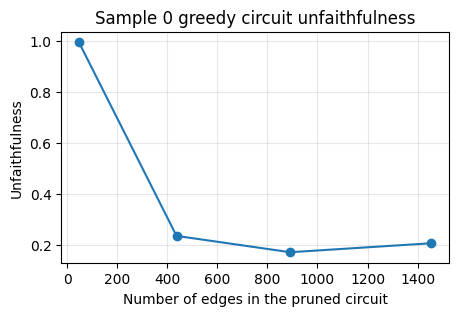

In [41]:
sample_idx = 0
sample_row = greedy_df.iloc[sample_idx]

n_edges_real = sample_row["greedy_n_edges_real"]
unfaithfulness = abs(1 - sample_row["greedy_metric_faithfulness_train"])

plt.figure(figsize=(5, 3))
plt.plot(n_edges_real, unfaithfulness, marker="o")
plt.xlabel("Number of edges in the pruned circuit")
plt.ylabel("Unfaithfulness")
plt.title(f"Sample {sample_idx} greedy circuit unfaithfulness")
plt.grid(alpha=0.3)
plt.show()
